# What is the First Day of the Week?

Whether the Gregorian calendar shows Sunday or Monday as the first day of the week depends on where you live.

Do more countries start the week on Sunday or Monday? What about people? What about by continent?

The file `first-day-of-week.csv` shows the first day of the week for each territory. The file `population.csv` shows the population in the year 2020 for each territory in millions, and the file `four-regions.csv` specifies whether each territory is in asia, europe, africa, or the americas. 


In [2]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'first-day-of-week.csv', 'population.csv', and 'four-regions.csv'.

# from google.colab import files
# uploaded = files.upload()

In [3]:
import pandas as pd
df = pd.read_csv('first-day-of-week.csv')
df.head()

,territory,alpha3,first_day,units,paper
0,Afghanistan,AFG,sat,metric,A4
1,Aland Islands,ALA,mon,metric,A4
2,Albania,ALB,mon,metric,A4
3,Algeria,DZA,sat,metric,A4
4,American Samoa,ASM,sun,metric,A4


In [4]:
pop = pd.read_csv('population.csv')
pop.head()

,alpha3,population
0,AFG,39.07
1,ALB,2.87
2,DZA,44.04
3,AND,0.08
4,AGO,33.45


In [5]:
regions = pd.read_csv('four-regions.csv')
regions.head()

,alpha3,four_regions
0,AUS,asia
1,BRN,asia
2,KHM,asia
3,CHN,asia
4,FJI,asia


### Project Ideas

- How many territories show Friday, Saturday, Sunday, and Monday as the `first_day` of the week?

- How many people start the week on Friday, Saturday, Sunday, and Monday?
	- Hint: This will involve a `merge`.

- Which of the `four_regions` predominantly start the week on Sunday? On Monday? Are there any regions that are more divided between Sunday and Monday?
	- Hint: This will also involve a `merge`.

  first_day  territory
0       fri          1
1       mon        186
2       sat         15
3       sun         55


Text(0, 0.5, 'Number of terriories')

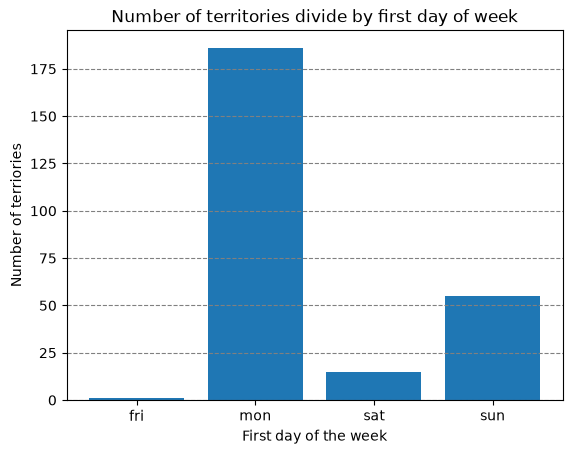

In [35]:
import matplotlib.pyplot as plt


first_day_by_territory = df.groupby('first_day')['territory'].count().reset_index()

print(first_day_by_territory)
quantity = first_day_by_territory['territory']
day = first_day_by_territory['first_day']

#plt.pie(quantity, labels = day, autopct ='%1.1f%%')
plt.bar(day,quantity)
plt.grid(axis='y', linestyle='--', alpha = 1, color= 'gray')
plt.title("Number of territories divide by first day of week")
plt.xlabel("First day of the week")
plt.ylabel("Number of terriories")



From the last chart, only one territory start the week on Friday, more people start on Monday (186 territories), 15 territories on Saturday and 55 on Sunday

The next result shows the population by day. That numbers are in millions

In [47]:
pop.head()

merged_df = pop.merge(df, on = "alpha3", how = 'left')

merged_df.groupby('first_day')['population'].count().reset_index()




,first_day,population
0,fri,1
1,mon,131
2,sat,15
3,sun,49


- Which of the `four_regions` predominantly start the week on Sunday? On Monday? Are there any regions that are more divided between Sunday and Monday?
	- Hint: This will also involve a `merge`.

Text(0.5, 0.98, 'Regions divide by first day of week')

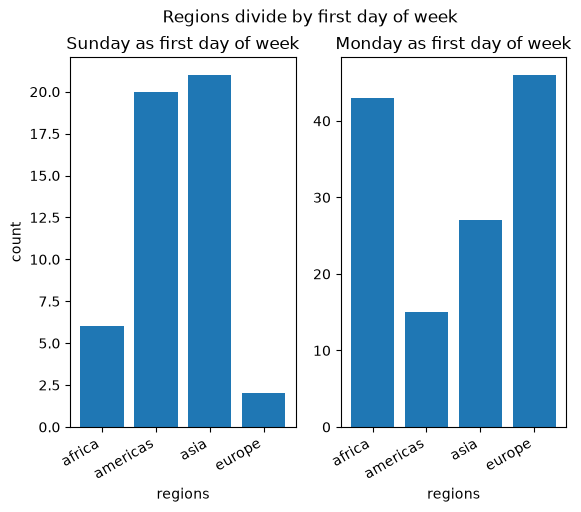

In [ ]:
## merging
by_regions_df = regions.merge(df, on= 'alpha3', how = 'left')

## Sunday
sun_region = by_regions_df.query('first_day == "sun"')
df_data = sun_region.groupby('four_regions')['first_day'].count().reset_index()

## Monday
Mon_region = by_regions_df.query('first_day == "mon"')
df_data_mon = Mon_region.groupby('four_regions')['first_day'].count().reset_index()

# plot 1
plt.subplot(1,2,1)
x_sun = df_data['four_regions']
y_sun =df_data['first_day']

plt.bar(x_sun,y_sun)
plt.xticks(rotation=30, ha='right')
plt.title('Sunday as first day of week')
plt.xlabel('regions')
plt.ylabel('count')

#plot 2
plt.subplot(1,2,2)
x_mon = df_data_mon['four_regions']
y_mon = df_data_mon['first_day']
plt.bar(x_mon,y_mon)
plt.xticks(rotation=30, ha='right')
plt.title('Monday as first day of week')
plt.xlabel('regions')

plt.suptitle("Regions divide by first day of week")




From the follow analysis America and Asia are more divided between Monday and Sunday as first day

some notes: 
- alpha: define partial transparency
- label: to identify the day. Allows add tags for the legend
- plt.legend() : shows the labels added 

Text(0.5, 1.0, 'Regions divided by first day of the week')

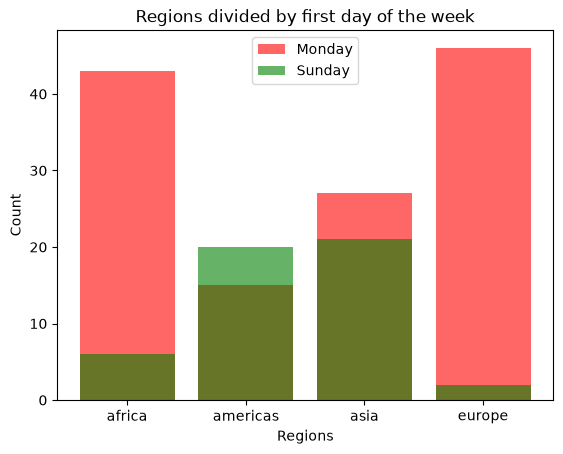

In [106]:
# comparing 

plt.bar(x_mon,y_mon, color='red', alpha=0.6, label='Monday')

plt.bar(x_sun,y_sun, color='green', alpha=0.6, label='Sunday')

plt.legend()
plt.xlabel('Regions')
plt.ylabel('Count')
plt.title("Regions divided by first day of the week")
